In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries ready!")

Libraries ready!


In [8]:
df = pd.read_csv('Student_performance_cleaned.csv')

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 2392, Columns: 15


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,Female,0,2,19.83,7,Yes,2,No,No,Yes,No,2.9292,2
1,1002,18,Male,0,1,15.41,0,No,1,No,No,No,No,3.0429,1
2,1003,15,Male,2,3,4.21,26,No,2,No,No,No,No,0.1126,4
3,1004,17,Female,0,3,10.03,14,No,3,Yes,No,No,No,2.0542,3
4,1005,17,Female,0,2,4.67,17,Yes,3,No,No,No,No,1.2881,4


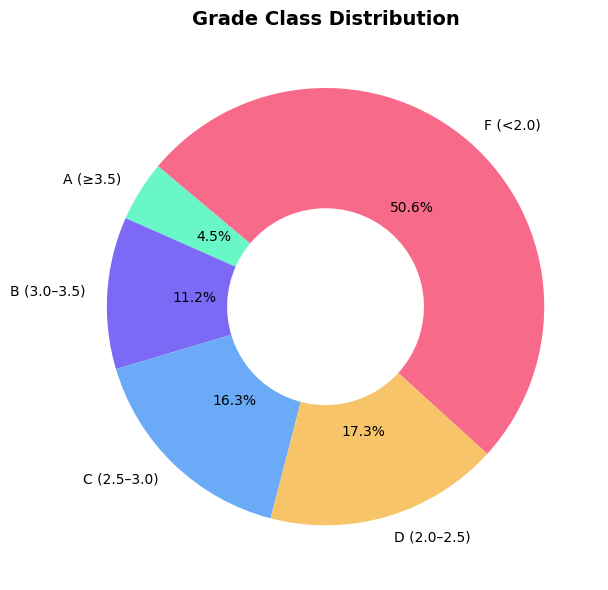

In [9]:
grade_counts = df['GradeClass'].value_counts().sort_index()
labels = ['A (≥3.5)', 'B (3.0–3.5)', 'C (2.5–3.0)', 'D (2.0–2.5)', 'F (<2.0)']
colors = ['#6af7c8', '#7c6af7', '#6aaaf7', '#f7c46a', '#f76a8a']

plt.figure(figsize=(7, 6))
wedges, texts, autotexts = plt.pie(
    grade_counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.55)
)
plt.title('Grade Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

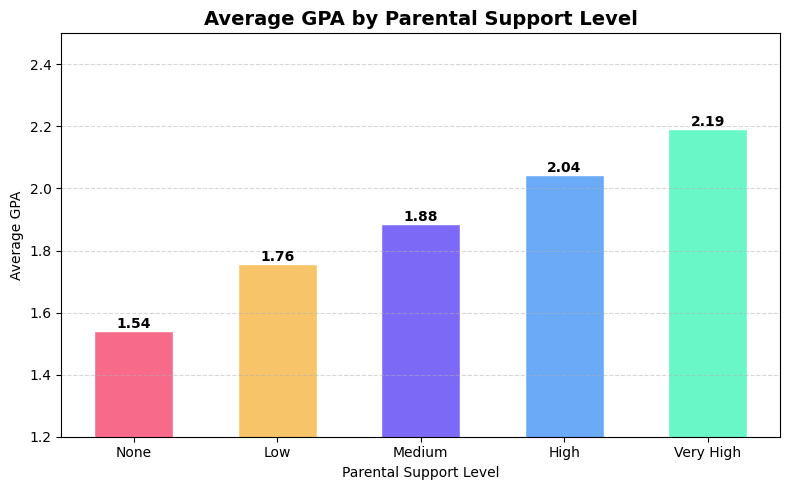

In [10]:
support_gpa = df.groupby('ParentalSupport')['GPA'].mean().round(3)
support_gpa.index = ['None', 'Low', 'Medium', 'High', 'Very High']

plt.figure(figsize=(8, 5))
bars = plt.bar(support_gpa.index, support_gpa.values,
               color=['#f76a8a', '#f7c46a', '#7c6af7', '#6aaaf7', '#6af7c8'],
               edgecolor='white', width=0.55)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold')

plt.ylim(1.2, 2.5)
plt.xlabel('Parental Support Level')
plt.ylabel('Average GPA')
plt.title('Average GPA by Parental Support Level', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

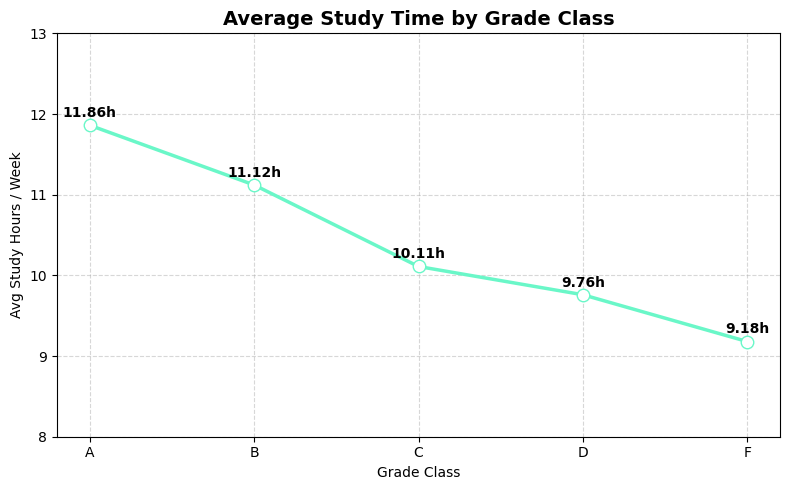

In [11]:
study_grade = df.groupby('GradeClass')['StudyTimeWeekly'].mean().round(2)
study_grade.index = ['A', 'B', 'C', 'D', 'F']

plt.figure(figsize=(8, 5))
plt.plot(study_grade.index, study_grade.values,
         color='#6af7c8', linewidth=2.5, marker='o',
         markersize=9, markerfacecolor='white')

for x, y in zip(study_grade.index, study_grade.values):
    plt.text(x, y + 0.1, f'{y:.2f}h', ha='center', fontsize=10, fontweight='bold')

plt.ylim(8, 13)
plt.xlabel('Grade Class')
plt.ylabel('Avg Study Hours / Week')
plt.title('Average Study Time by Grade Class', fontsize=14, fontweight='bold')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

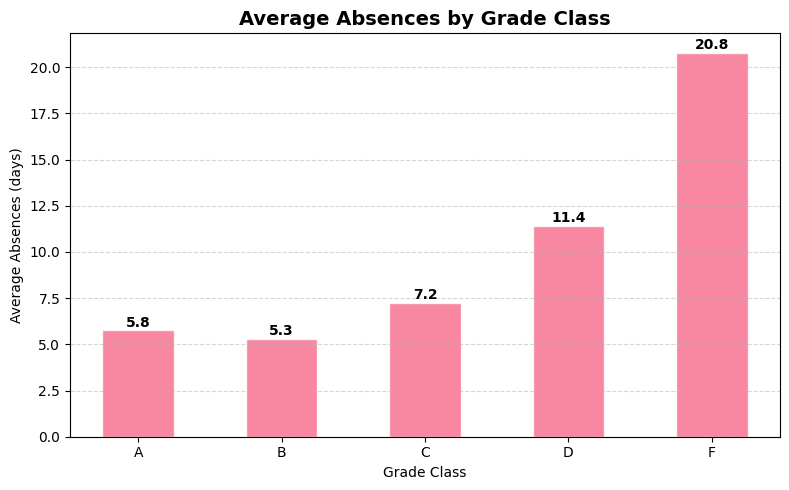

In [12]:
abs_grade = df.groupby('GradeClass')['Absences'].mean().round(2)
abs_grade.index = ['A', 'B', 'C', 'D', 'F']

plt.figure(figsize=(8, 5))
bars = plt.bar(abs_grade.index, abs_grade.values,
               color='#f76a8a', alpha=0.8, edgecolor='white', width=0.5)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}', ha='center', fontsize=10, fontweight='bold')

plt.xlabel('Grade Class')
plt.ylabel('Average Absences (days)')
plt.title('Average Absences by Grade Class', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

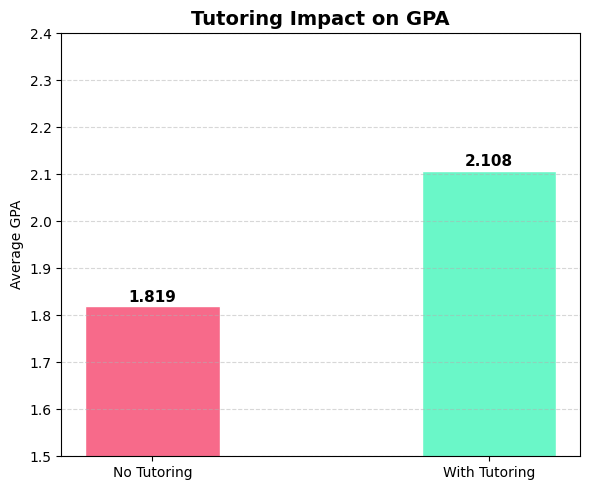

In [13]:
tutor_gpa = df.groupby('Tutoring')['GPA'].mean().round(3)
tutor_gpa.index = ['No Tutoring', 'With Tutoring']

plt.figure(figsize=(6, 5))
bars = plt.bar(tutor_gpa.index, tutor_gpa.values,
               color=['#f76a8a', '#6af7c8'], edgecolor='white', width=0.4)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=11, fontweight='bold')

plt.ylim(1.5, 2.4)
plt.ylabel('Average GPA')
plt.title('Tutoring Impact on GPA', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

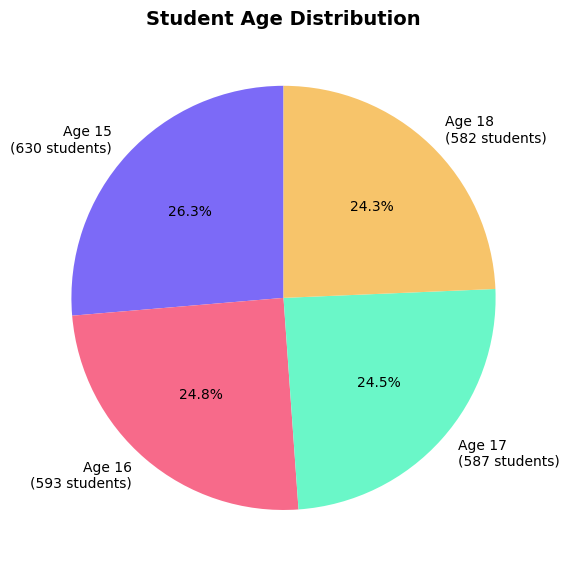

In [14]:
age_counts = df['Age'].value_counts().sort_index()

plt.figure(figsize=(6, 6))
plt.pie(age_counts.values,
        labels=[f'Age {a}\n({c} students)' for a, c in zip(age_counts.index, age_counts.values)],
        colors=['#7c6af7', '#f76a8a', '#6af7c8', '#f7c46a'],
        autopct='%1.1f%%',
        startangle=90)

plt.title('Student Age Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

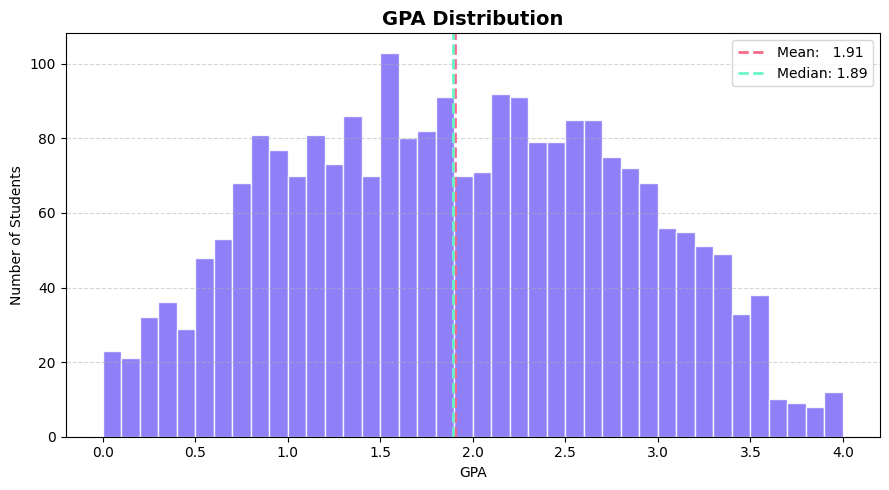

In [18]:

plt.figure(figsize=(9, 5))
plt.hist(df['GPA'], bins=40, color='#7c6af7', alpha=0.85, edgecolor='white')
plt.axvline(df['GPA'].mean(),   color='#f76a8a', linestyle='--', linewidth=2,
            label=f'Mean:   {df["GPA"].mean():.2f}')
plt.axvline(df['GPA'].median(), color='#6af7c8', linestyle='--', linewidth=2,
            label=f'Median: {df["GPA"].median():.2f}')

plt.xlabel('GPA')
plt.ylabel('Number of Students')
plt.title('GPA Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


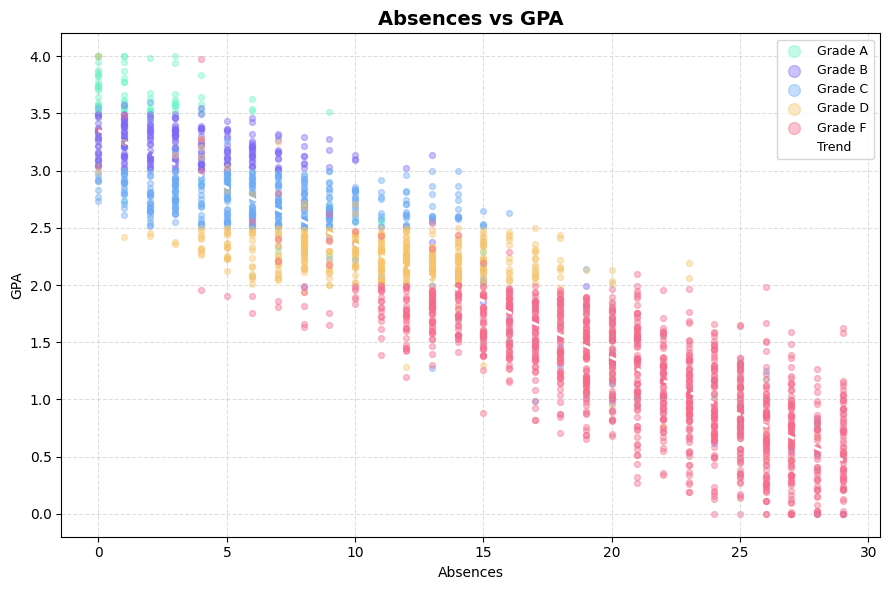

In [19]:

grade_colors = {0.0: '#6af7c8', 1.0: '#7c6af7',
                2.0: '#6aaaf7', 3.0: '#f7c46a', 4.0: '#f76a8a'}
grade_names  = {0.0: 'A', 1.0: 'B', 2.0: 'C', 3.0: 'D', 4.0: 'F'}

plt.figure(figsize=(9, 6))
for grade, grp in df.groupby('GradeClass'):
    plt.scatter(grp['Absences'], grp['GPA'],
                c=grade_colors[grade], alpha=0.4, s=18,
                label=f'Grade {grade_names[grade]}')

# Trend line
z = np.polyfit(df['Absences'], df['GPA'], 1)
x_line = np.linspace(df['Absences'].min(), df['Absences'].max(), 100)
plt.plot(x_line, np.poly1d(z)(x_line), 'white', linewidth=2,
         linestyle='--', label='Trend')

plt.xlabel('Absences')
plt.ylabel('GPA')
plt.title('Absences vs GPA', fontsize=14, fontweight='bold')
plt.legend(fontsize=9, markerscale=2)
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
